# SNR_Folded

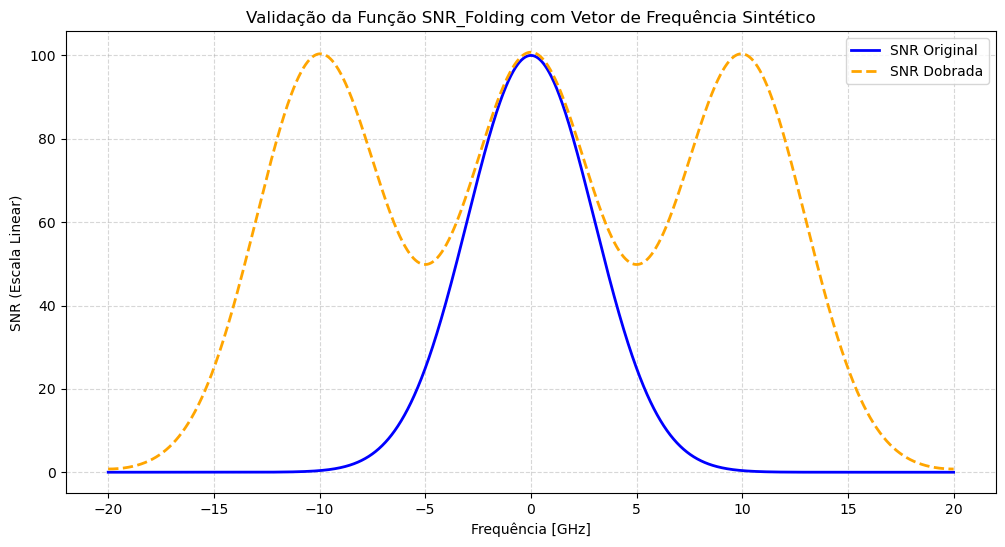

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def SNR_Folding(SNR, f, mu, Rs):
    """
    Folds the SNR  on a bandwith equal to the symbol rate.

    param:
        SNR (np.array): SNR vector linear
        f (np.array): Frequency vector
        mu (int): Number of foldings
        Rs (float): Symbol rate [Baud]
    returns:
        SNR_folded (np.array): Folded SNR vector linear
    """

    df = f[1]-f[0]
    SNR_folded = np.zeros_like(SNR)
    shift = int(round(Rs/df))

    for i in range(-mu, mu+1):
        SNR_folded += np.roll(SNR, i*shift)
    return SNR_folded

Rs = 10e9  
Fs = 40e9   
N = 4096    

f = np.linspace(-Fs/2, Fs/2, N)
sigma = 1.5e9*2
SNR_original_linear = np.exp(-f**2 / (2 * sigma**2)) * 100  # Pico de 100 de SNR linear

mu_teste = 1
SNR_dobrada_linear = SNR_Folding(SNR_original_linear, f, mu_teste, Rs)

plt.figure(figsize=(12, 6))

# Plot da SNR Original
plt.plot(f / 1e9, SNR_original_linear, label='SNR Original', color='blue', linewidth=2)

# Plot da SNR Dobrada (Folded)
plt.plot(f / 1e9, SNR_dobrada_linear, label=f'SNR Dobrada', 
         color='orange', linestyle='--', linewidth=2)

plt.title('Validação da Função SNR_Folding com Vetor de Frequência Sintético')
plt.xlabel('Frequência [GHz]')
plt.ylabel('SNR (Escala Linear)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper right')

plt.show()

# SNR_DFE

In [8]:
def SNR_DFE(SNR_folded, f, Rs):
    """
    calculates the SNR at the output of a Decision Feedback Equalizer (DFE) based on the folded SNR.

    param:
        SNR_Folded (np.array): Folded SNR vector linear
        f (np.array): Frequency vector
        Rs (float): Symbol rate [Baud]
    returns:
        SNR_DFE (np.array): SNR at the output of the DFE
    """

    lim_inf = -Rs/2
    lim_sup = Rs/2
    T = 1/Rs

    idx = np.where((f >= lim_inf) & (f <= lim_sup))
    SNR_DFE = np.exp((T*np.trapezoid(np.log(SNR_folded[idx]+1), f[idx]))) - 1
    return SNR_DFE



In [ ]:
Rs = 10e9       
Fs = 40e9       
N = 100000      
f = np.linspace(-Fs/2, Fs/2, N)

SNR_teste_2 = np.where(f < 0, 0.0, 15.0)
resultado_2 = SNR_DFE(SNR_teste_2, f, Rs)
sucesso_2 = np.isclose(resultado_2, 3.0, atol=1e-3)

print("Teste 2 (SNR em Degrau: 0.0 e 15.0):")
print(f"  -> Esperado Teórico: 3.0")
print(f"  -> Obtido:           {resultado_2:.6f}")
print(f"  -> Status:           {'PASSED (Sucesso!)' if sucesso_2 else 'FAILED (Erro!)'}\n")

print("---------------------------------------------")

Teste 2 (SNR em Degrau: 0.0 e 15.0):
  -> Esperado Teórico: 3.0
  -> Obtido:           2.999834
  -> Status:           PASSED (Sucesso!)

---------------------------------------------
